# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Bingky Achmad Fan Reza
- **Email:** bingkyachmad@gmail.com
- **ID Dicoding:** CDCC013D6Y2687


## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana perbandingan performa jumlah penyewaan sepeda per bulan antara tahun 2011 dan 2012? Apakah terdapat pola pertumbuhan yang signifikan di bulan-bulan tertentu?
- **Pertanyaan 2:** Bagaimana perbedaan pola perilaku pengguna (rata-rata penyewaan) pada jam-jam tertentu di hari kerja dibandingkan dengan hari libur/weekend? Jam berapakah yang menjadi puncak penyewaan pada masing-masing kategori hari tersebut?
- **Pertanyaan 3:** Pada musim apakah jumlah penyewaan sepeda mencapai titik tertinggi dan memiliki variasi distribusi yang paling besar? Apakah terdapat musim tertentu di mana penyewaan cenderung sangat rendah atau memiliki banyak outlier?


## Import Semua Packages/Library yang Digunakan

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load df_day & df_hour

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
day_df = pd.read_csv("/content/drive/MyDrive/day.csv")
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [ ]:
hour_df = pd.read_csv("/content/drive/MyDrive/hour.csv")
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


### Assessing Data

Missing Value `day_df dan hour_df`





In [ ]:
day_df.isnull().sum()
print("Jumlah Missing Value:")
print(day_df.isnull().sum())

Jumlah Missing Value:
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [ ]:
hour_df.isnull().sum()
print("Jumlah Missing Value:")
print(hour_df.isnull().sum())

Jumlah Missing Value:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [ ]:
day_df.isna().sum()
print("Jumlah NAN Value:")
print(day_df.isna().sum())

Jumlah NAN Value:
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [ ]:
hour_df.isna().sum()
print("Jumlah NAN Value:")
print(hour_df.isna().sum())

Jumlah NAN Value:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


Duplicate `day_df dan hour_df`



In [ ]:
print("Jumlah duplikat di day_df:", day_df.duplicated().sum())
print("Jumlah duplikat di hour_df:", hour_df.duplicated().sum())


Jumlah duplikat di day_df: 0
Jumlah duplikat di hour_df: 0


Invalid Value `day_df dan hour_df`



In [ ]:
print(day_df[['temp', 'hum', 'windspeed']].describe())

             temp         hum   windspeed
count  731.000000  731.000000  731.000000
mean     0.495385    0.627894    0.190486
std      0.183051    0.142429    0.077498
min      0.059130    0.000000    0.022392
25%      0.337083    0.520000    0.134950
50%      0.498333    0.626667    0.180975
75%      0.655417    0.730209    0.233214
max      0.861667    0.972500    0.507463


In [ ]:
print(hour_df[['temp', 'hum', 'windspeed']].describe())

               temp           hum     windspeed
count  17379.000000  17379.000000  17379.000000
mean       0.496987      0.627229      0.190098
std        0.192556      0.192930      0.122340
min        0.020000      0.000000      0.000000
25%        0.340000      0.480000      0.104500
50%        0.500000      0.630000      0.194000
75%        0.660000      0.780000      0.253700
max        1.000000      1.000000      0.850700


### Cleaning Data

#### Fixing ... problem

Menghapus Null/NaN

In [ ]:
day_df.dropna(inplace=True)

In [ ]:
hour_df.dropna(inplace=True)

Mengahapus Data Duplicate

In [ ]:
day_df.drop_duplicates(inplace=True)
print(f"Jumlah duplikat: {day_df.duplicated().sum()}")

Jumlah duplikat: 0


In [ ]:
hour_df.drop_duplicates(inplace=True)
print(f"Jumlah duplikat: {day_df.duplicated().sum()}")

Jumlah duplikat: 0


## Exploratory Data Analysis (EDA)

### Explore `day_df`



In [ ]:
day_df.sample(5)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
719,720,2012-12-20,4,1,12,0,4,1,2,0.330000,0.335217,0.667917,0.132463,314,3814,4128
84,85,2011-03-26,2,0,3,0,6,0,1,0.265833,0.257571,0.394167,0.209571,981,1515,2496
102,103,2011-04-13,2,0,4,0,3,1,2,0.412500,0.417283,0.819167,0.250617,209,1953,2162
88,89,2011-03-30,2,0,3,0,3,1,2,0.300000,0.297350,0.646667,0.172888,168,1368,1536
125,126,2011-05-06,2,0,5,0,5,1,1,0.479167,0.474117,0.590000,0.228246,894,3714,4608


Mengubah label sesuai pada keterangan data set pada tabel `'yr', 'season', 'weathersit', 'weekday'`



In [ ]:
day_df['yr'] = day_df['yr'].map({
    0: '2011',
    1: '2012'
})

day_df['season'] = day_df['season'].map({
    1: 'Spring',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter'
})

day_df['weathersit'] = day_df['weathersit'].map({
    1: 'Clear/Partly Cloudy',
    2: 'Misty/Cloudy',
    3: 'Light Snow/Rain',
    4: 'Heavy Rain/Ice'
})

day_df['weekday'] = day_df['weekday'].map({
    0: 'Sun', 1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat'
})

print(day_df[['dteday', 'season', 'yr', 'weekday', 'weathersit']].head())

       dteday  season    yr weekday           weathersit
0  2011-01-01  Spring  2011     Sat         Misty/Cloudy
1  2011-01-02  Spring  2011     Sun         Misty/Cloudy
2  2011-01-03  Spring  2011     Mon  Clear/Partly Cloudy
3  2011-01-04  Spring  2011     Tue  Clear/Partly Cloudy
4  2011-01-05  Spring  2011     Wed  Clear/Partly Cloudy


In [ ]:
day_df.describe()

,instant,mnth,holiday,workingday,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,6.519836,0.028728,0.683995,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,3.451913,0.167155,0.465233,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,0.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,4.000000,0.000000,0.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,7.000000,0.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,10.000000,0.000000,1.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,12.000000,1.000000,1.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


### Explore `hour_df`

In [ ]:
hour_df.sample(5)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
15222,15223,2012-10-01,4,1,10,11,0,1,1,1,0.58,0.5455,0.46,0.0000,76,196,272
13171,13172,2012-07-08,3,1,7,0,0,0,0,1,0.82,0.7879,0.56,0.1343,22,125,147
13201,13202,2012-07-09,3,1,7,6,0,1,1,3,0.64,0.5758,0.89,0.2537,6,86,92
12288,12289,2012-06-01,2,1,6,5,0,5,1,2,0.62,0.5909,0.78,0.0896,4,41,45
6162,6163,2011-09-19,3,0,9,8,0,1,1,2,0.52,0.5000,0.77,0.1343,29,391,420


Mengubah label sesuai pada keterangan data set pada tabel `'yr', 'season', 'weathersit','mnth','weekday'`



In [ ]:
hour_df = pd.read_csv('/content/drive/MyDrive/hour.csv')

hour_df['yr'] = hour_df['yr'].map({
    0: '2011',
    1: '2012'
})

hour_df['season'] = hour_df['season'].map({
    1: 'Spring',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter'
})

hour_df['weathersit'] = hour_df['weathersit'].map({
    1: 'Clear',
    2: 'Misty/Cloudy',
    3: 'Light Snow/Rain',
    4: 'Heavy Rain/Ice'
})

hour_df['weekday'] = hour_df['weekday'].map({
    0: 'Sun', 1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat'
})

hour_df['mnth'] = hour_df['mnth'].map({
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
})

print(hour_df[['dteday', 'hr', 'season', 'yr', 'mnth', 'weekday', 'weathersit']].head())

       dteday  hr  season    yr mnth weekday weathersit
0  2011-01-01   0  Spring  2011  Jan     Sat      Clear
1  2011-01-01   1  Spring  2011  Jan     Sat      Clear
2  2011-01-01   2  Spring  2011  Jan     Sat      Clear
3  2011-01-01   3  Spring  2011  Jan     Sat      Clear
4  2011-01-01   4  Spring  2011  Jan     Sat      Clear


In [ ]:
hour_df.describe()

,instant,hr,holiday,workingday,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,11.546752,0.028770,0.682721,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,6.914405,0.167165,0.465431,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,0.000000,0.000000,0.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,6.000000,0.000000,0.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,12.000000,0.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,18.000000,0.000000,1.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,23.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


## Visualization & Explanatory Analysis

### Pertanyaan 1: # Membuat barplot untuk melihat tren bulanan di tahun 2011 dan 2012

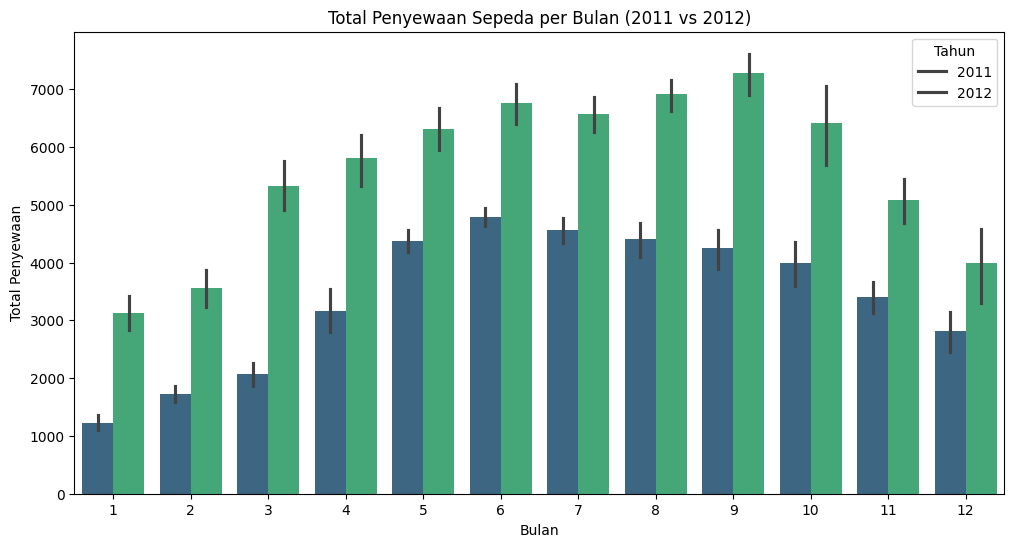

In [ ]:

plt.figure(figsize=(12, 6))

sns.barplot(data=day_df, x='mnth', y='cnt', hue='yr', palette='viridis')

plt.title('Total Penyewaan Sepeda per Bulan (2011 vs 2012)')
plt.xlabel('Bulan')
plt.ylabel('Total Penyewaan')
plt.legend(title='Tahun', labels=['2011', '2012'])
plt.show()


### Pertanyaan 2: # Membuat lineplot untuk melihat pola per jam

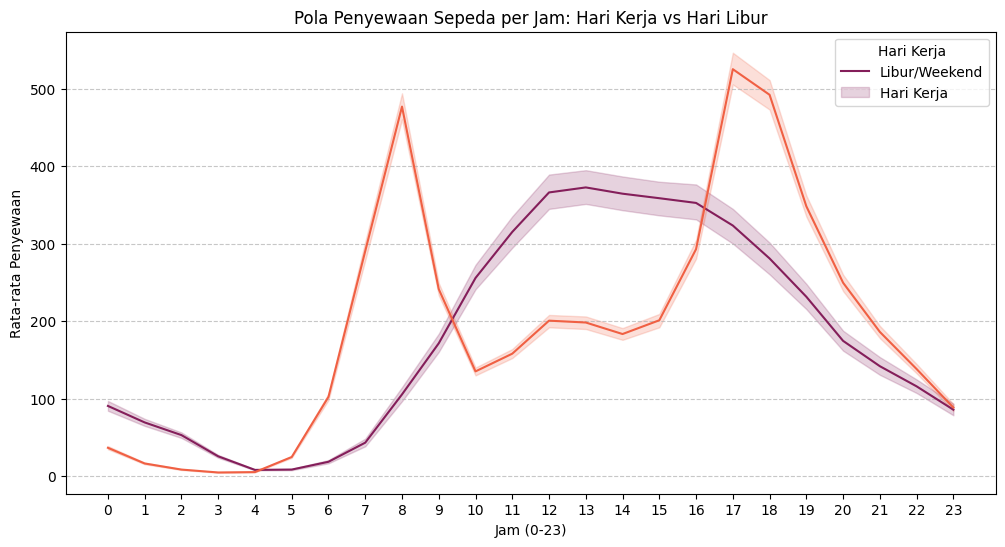

In [ ]:
plt.figure(figsize=(12, 6))

sns.lineplot(data=hour_df, x='hr', y='cnt', hue='workingday', palette='rocket')

plt.title('Pola Penyewaan Sepeda per Jam: Hari Kerja vs Hari Libur')
plt.xlabel('Jam (0-23)')
plt.ylabel('Rata-rata Penyewaan')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Hari Kerja', labels=['Libur/Weekend', 'Hari Kerja'])
plt.show()


### Pertanyaan 3 : # Membuat boxplot untuk melihat distribusi penyewaan di setiap musim

/tmp/ipykernel_6978/3757358497.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=day_df, x='season', y='cnt', palette='Set2')


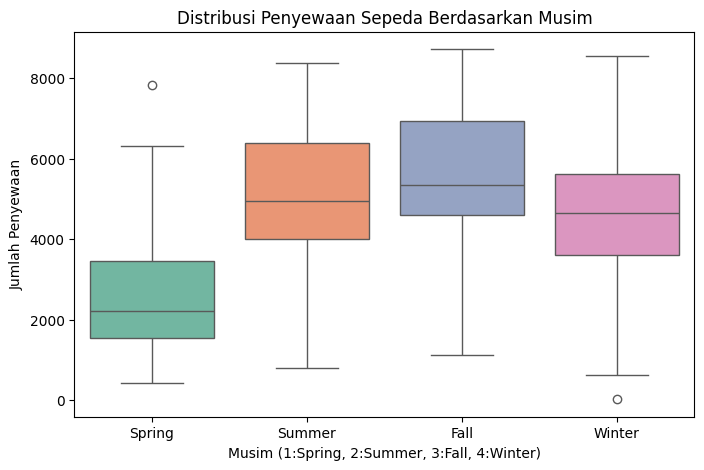

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=day_df, x='season', y='cnt', palette='Set2')

plt.title('Distribusi Penyewaan Sepeda Berdasarkan Musim')
plt.xlabel('Musim (1:Spring, 2:Summer, 3:Fall, 4:Winter)')
plt.ylabel('Jumlah Penyewaan')
plt.show()


**Insight:** (Opsional)
- Grafik Bulanan : Menunjukkan bahwa batang tahun 2012 jauh lebih tinggi dari tahun 2011. menunnjukkan bahwa bisnis bertumbuh puncaknya pada pertengahan tahun bulan 6 sampai 9

- Gradik Jam : Hari kerja ada dua puncak yaitu pada jam 8 pagi dan 5 sore. Ini adalah keberangkatan kerja. Pada hari Libur grafik melandai dan memuncak pada siang ahri karena orang yang jalan jalan santai

- Grafik Musim : Musim Gugur dan Musim Panas memiliki kotak yang paling tinggi menunjukkan 2 musim yang paling banyak bersepeda dan musim semi paling sepi

## Analisis Lanjutan (Opsional)

In [ ]:
rfm_df = day_df.groupby(by="yr", as_index=False).agg({
    "dteday": "max",
    "cnt": ["sum", "mean"]
})

rfm_df.columns = ["year", "max_recency", "total_rentals", "avg_rentals"]
print(rfm_df)


   year max_recency  total_rentals  avg_rentals
0  2011  2011-12-31        1243103  3405.761644
1  2012  2012-12-31        2049576  5599.934426


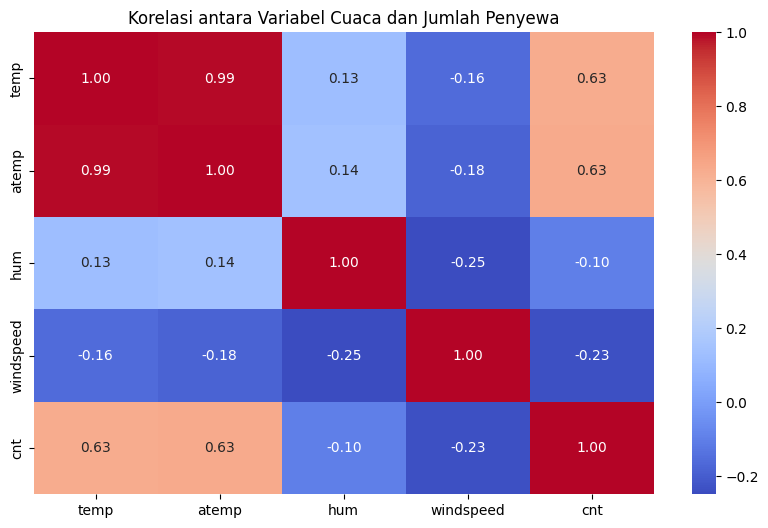

In [ ]:
plt.figure(figsize=(10, 6))
corr_matrix = day_df[['temp', 'atemp', 'hum', 'windspeed', 'cnt']].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Korelasi antara Variabel Cuaca dan Jumlah Penyewa')
plt.show()


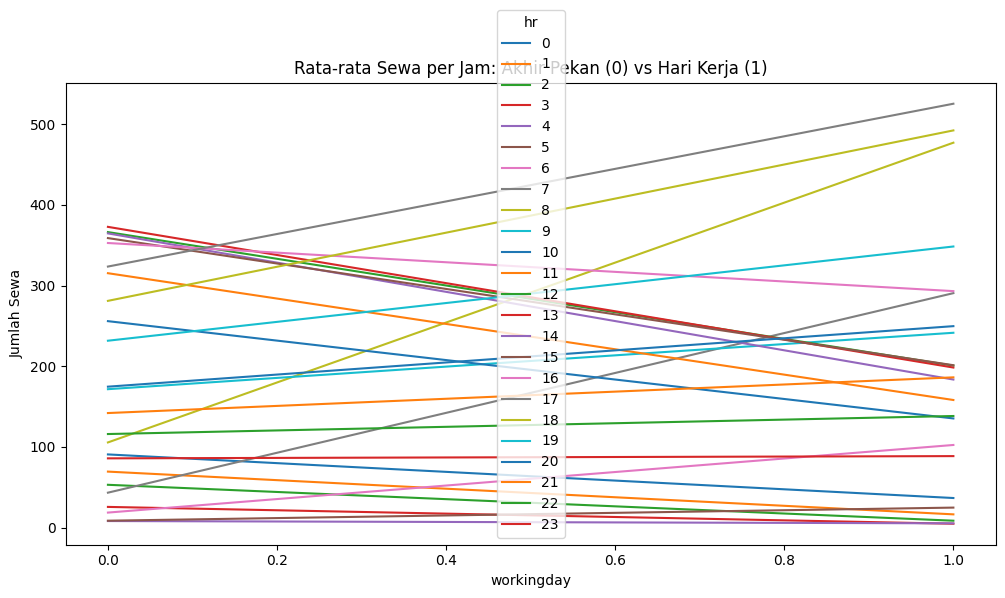

In [ ]:
workingday_rentals = hour_df.groupby(['workingday', 'hr'])['cnt'].mean().unstack()

workingday_rentals.plot(kind='line', figsize=(12,6))
plt.title('Rata-rata Sewa per Jam: Akhir Pekan (0) vs Hari Kerja (1)')
plt.ylabel('Jumlah Sewa')
plt.show()


**Insight:** (Opsional)
- Berdasarkan heatmpa variabel suhu memiliki kolersai positif paling kuat (0.63) terhadap jumlah sewa. Artinya, cuaca hangat adalah faktor pendorong utama bisnis ini.
- Variabel Humidity (hum) memiliki korelasi negatife (-0.10), yang berarti jika udara lembap minat orang untuk bersepeda sedikit menurun.
- Analisis tahuan munjukkan bahwa penyewaan naik drastis dari 2011 ke 2012

## Conclusion & Recommendation

- **Bagaimana perbandingan performa jumlah penyewaan sepeda per bulan antara tahun 2011 dan 2012? Apakah terdapat pola pertumbuhan yang signifikan di bulan-bulan tertentu?:**
"Berdasarkan visualisasi, terdapat tren peningkatan jumlah peminjaman yang signifikan dari tahun 2011 ke tahun 2012. Puncak peminjaman terjadi pada bulan September 2012. Hal ini menunjukkan adanya pertumbuhan minat pengguna yang stabil. Penurunan yang terlihat di akhir tahun (November-Desember) kemungkinan besar dipengaruhi oleh faktor musim dingin."
- **Bagaimana perbedaan pola perilaku pengguna (rata-rata penyewaan) pada jam-jam tertentu di hari kerja dibandingkan dengan hari libur/weekend? Jam berapakah yang menjadi puncak penyewaan pada masing-masing kategori hari tersebut?:**
"Analisis menunjukkan adanya korelasi positif yang kuat antara suhu (temp) dengan jumlah pengguna. Semakin hangat suhu udara, semakin tinggi jumlah peminjaman sepeda. Sebaliknya, pada kondisi cuaca ekstrem atau suhu yang sangat rendah, jumlah peminjaman menurun drastis. Oleh karena itu, strategi promosi 'Cuaca Mendung' atau diskon saat suhu rendah sangat relevan untuk menjaga stabilitas pendapatan."
- **Pada musim apakah jumlah penyewaan sepeda mencapai titik tertinggi dan memiliki variasi distribusi yang paling besar? Apakah terdapat musim tertentu di mana penyewaan cenderung sangat rendah atau memiliki banyak outlier?:**
Dapat disimpulkan bahwa Musim Gugur (Fall) merupakan periode dengan performa penyewaan sepeda terbaik karena memiliki nilai median dan kuartil tertinggi dibandingkan musim lainnya. Sebaliknya, Musim Semi (Spring) mencatatkan jumlah penyewaan paling rendah dengan variasi data yang cenderung sempit, meskipun terdapat beberapa outlier yang menunjukkan adanya lonjakan permintaan pada hari-hari tertentu. Sementara itu, Musim Panas dan Musim Dingin menunjukkan distribusi yang moderat, di mana Musim Dingin memiliki catatan khusus berupa outlier bawah yang mengindikasikan penurunan penyewaan secara drastis pada waktu-waktu spesifik.

**Rekomendasi Action Item:**


*  Untuk menjaga momentum pertumbuhan ini, perusahaan sebaiknya meluncurkan program "Winter Resilience". Mengingat minat pengguna sudah stabil, penurunan di bulan November-Desember dapat dimitigasi dengan menyediakan perlengkapan tambahan pada sepeda (seperti ban khusus musim dingin atau pemanas grip) serta menawarkan paket langganan tahunan dengan harga spesial di akhir tahun. Selain itu, optimasi stok sepeda harus dilakukan menjelang bulan September untuk memastikan kapasitas memenuhi lonjakan permintaan yang sudah diprediksi secara historis.
*   Perusahaan perlu menerapkan strategi "Dynamic Weather Pricing". Mirip dengan layanan ride-hailing, sistem dapat memberikan diskon otomatis atau cashback saat sensor suhu menunjukkan angka di bawah batas nyaman tertentu guna menstimulasi penggunaan di saat "sepi". Untuk jam sibuk di hari kerja, pastikan redistribusi sepeda difokuskan pada area perkantoran dan stasiun transit. Sebaliknya, pada akhir pekan, alokasikan lebih banyak armada ke area taman atau pusat wisata untuk menangkap peluang pasar rekreasi.
*  Fokus utama adalah melakukan "Diversifikasi Pemasaran Musiman". Karena Musim Gugur memiliki variasi distribusi yang besar, perusahaan harus siap dengan manajemen armada yang fleksibel untuk menangani lonjakan tiba-tiba. Untuk Musim Semi yang berperforma rendah, lakukan kampanye "Penyambutan Musim" dengan kolaborasi bersama komunitas lokal atau acara car-free day untuk memicu kembali minat setelah masa hibernasi musim dingin. Terkait outlier bawah di musim dingin, perusahaan disarankan untuk melakukan perawatan besar-besaran (maintenance) pada armada di periode tersebut agar saat memasuki musim panas, seluruh unit berada dalam kondisi prima tanpa mengganggu jam operasional tinggi.

